In [2]:
%pip install pandas numpy matplotlib scikit-learn

  Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp314-cp314-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Usin


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import tarfile
import urllib.request
import pandas as pd

# URLs e caminhos para os dados do livro
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    print("Baixando o arquivo da internet...")
    urllib.request.urlretrieve(housing_url, tgz_path)
    print("Descompactando o arquivo...")
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()
    print("Concluído com sucesso!")

# Executa o download
fetch_housing_data()



Baixando o arquivo da internet...
Descompactando o arquivo...
Concluído com sucesso!


In [4]:


# Função para carregar os dados no Pandas
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

# Carrega o DataFrame
housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
# Exibe resumo das colunas, tipos de dados e valores nulos
housing.info()

# Exibe resumo estatístico dos atributos numéricos
housing.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
import numpy as np

# Define os pontos de corte baseados em tercis (33.3% e 66.7%)
corte_baixo, corte_medio = housing["median_house_value"].quantile([0.333, 0.667])

print(f"Limite Superior - Preço Baixo: US$ {corte_baixo:.2f}")
print(f"Limite Superior - Preço Médio: US$ {corte_medio:.2f}")

# Função para categorizar o valor do imóvel
def categorizar_preco(preco):
    if preco <= corte_baixo:
        return "Baixo"
    elif preco <= corte_medio:
        return "Médio"
    else:
        return "Elevado"

# Cria a coluna de rótulo (target) para o modelo de classificação
housing["price_category"] = housing["median_house_value"].apply(categorizar_preco)

# Exibe a quantidade de imóveis em cada classe
print("\nDistribuição das Classes de Preço:")
print(housing["price_category"].value_counts())

Limite Superior - Preço Baixo: US$ 141300.00
Limite Superior - Preço Médio: US$ 230400.00

Distribuição das Classes de Preço:
price_category
Médio      6893
Baixo      6876
Elevado    6871
Name: count, dtype: int64


Matplotlib is building the font cache; this may take a moment.


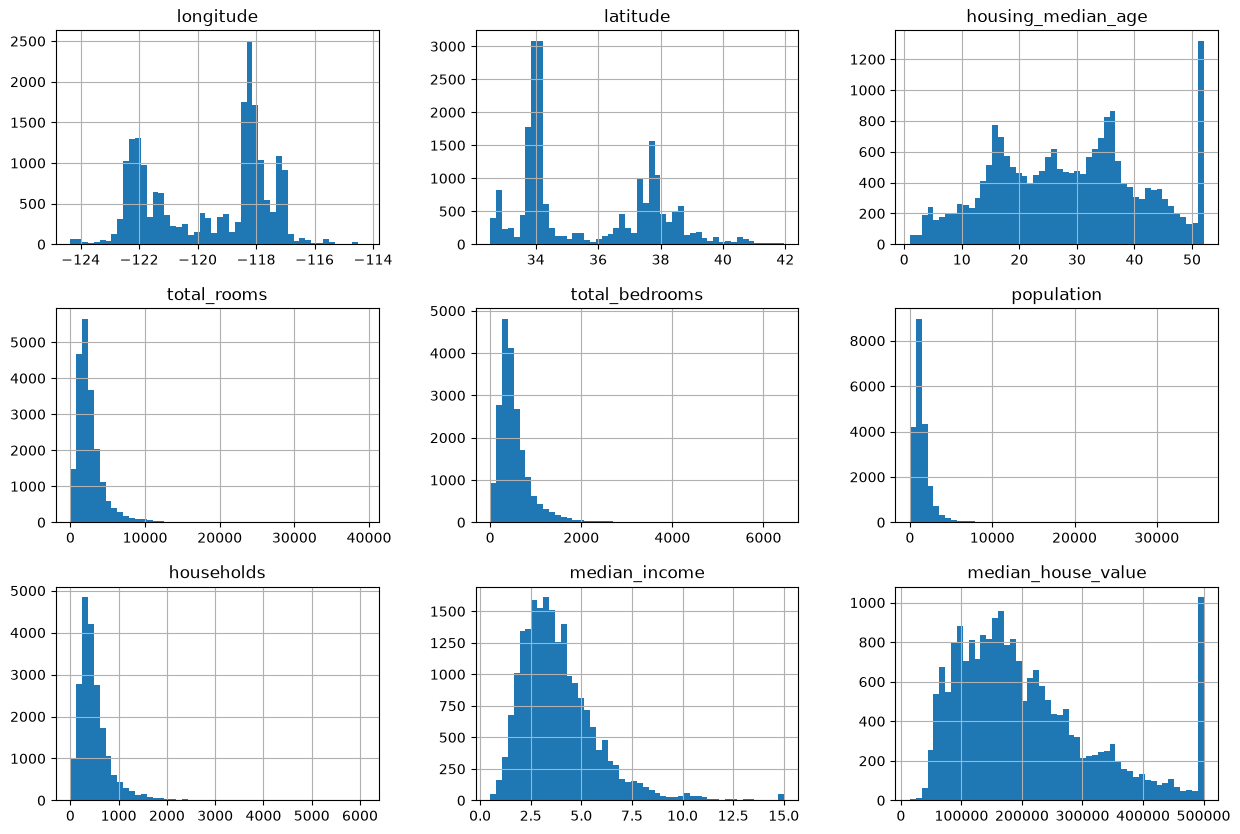

In [7]:
import matplotlib.pyplot as plt

# Plota o histograma de todos os atributos numéricos
housing.hist(bins=50, figsize=(15, 10))
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer # Substitui o Imputer antigo do livro
import numpy as np

# 1. Separamos os atributos previsores (X) e o rótulo/alvo (y)
# Removemos a coluna original de preço contínuo para o modelo não trapacear
X = housing.drop(["median_house_value", "price_category"], axis=1)
y = housing["price_category"]

# 2. Divisão Estratificada: 80% para treino e 20% para teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Instâncias no Treino: {len(X_train)}")
print(f"Instâncias no Teste: {len(X_test)}")

print("\nVerificando se a proporção das classes se manteve no Teste:")
print(y_test.value_counts(normalize=True) * 100)

Instâncias no Treino: 16512
Instâncias no Teste: 4128

Verificando se a proporção das classes se manteve no Teste:
price_category
Médio      33.406008
Baixo      33.309109
Elevado    33.284884
Name: proportion, dtype: float64


In [9]:
# Criamos uma cópia apenas com os atributos numéricos (o imputer não calcula mediana de texto)
X_train_num = X_train.drop("ocean_proximity", axis=1)

# Instanciamos o Imputer usando a estratégia da mediana
imputer = SimpleImputer(strategy="median")

# Ajustamos aos dados de treinamento e transformamos
X_train_num_preparado = imputer.fit_transform(X_train_num)

print("Valores ausentes tratados com sucesso usando a mediana!")

Valores ausentes tratados com sucesso usando a mediana!
